In [5]:
import pandas as pd
import numpy as np
import json
import re
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Affichage
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)

## 📥 Chargement des Données

In [6]:
def load_jsonl(filepath):
    """Charge un fichier JSONL en dataFrame, en ignorant les lignes mal formées."""
    data = []
    errors = 0
    with open(filepath, 'r', encoding='utf-8') as f:
        for i, line in enumerate(f):
            line = line.strip()
            if not line:  # Ignorer les lignes vides
                continue
            try:
                data.append(json.loads(line))
            except json.JSONDecodeError as e:
                errors += 1
                if errors <= 3:  # Afficher les 3 premières erreurs
                    print(f"Erreur ligne {i+1}: {e}")
    if errors > 0:
        print(f"Total: {errors} lignes ignorées à cause d'erreurs JSON")
    return data

# Chargement des données
train_data = load_jsonl('data/train.jsonl')
test_data = load_jsonl('data/kaggle_test.jsonl')

print(f"Train: {len(train_data)} tweets")
print(f"Test: {len(test_data)} tweets")

Train: 154914 tweets
Test: 103380 tweets


In [7]:
# Examiner la structure d'un tweet
sample = train_data[0]
print("Clés disponibles:")
print(list(sample.keys()))
print("\nClés user:")
if 'user' in sample:
    print(list(sample['user'].keys()))

Clés disponibles:
['quoted_status', 'in_reply_to_status_id_str', 'in_reply_to_status_id', 'created_at', 'in_reply_to_user_id_str', 'source', 'quoted_status_id', 'retweet_count', 'retweeted', 'geo', 'filter_level', 'in_reply_to_screen_name', 'is_quote_status', 'id_str', 'in_reply_to_user_id', 'favorite_count', 'text', 'place', 'quoted_status_permalink', 'lang', 'quote_count', 'favorited', 'coordinates', 'truncated', 'timestamp_ms', 'reply_count', 'entities', 'quoted_status_id_str', 'contributors', 'user', 'challenge_id', 'label']

Clés user:
['utc_offset', 'profile_image_url_https', 'listed_count', 'profile_background_image_url', 'default_profile_image', 'favourites_count', 'description', 'created_at', 'is_translator', 'profile_background_image_url_https', 'protected', 'profile_link_color', 'translator_type', 'geo_enabled', 'profile_background_color', 'lang', 'profile_sidebar_border_color', 'profile_text_color', 'profile_image_url', 'time_zone', 'url', 'contributors_enabled', 'profile_b

## 2.1 Features Textuelles Discriminantes

Les influenceurs ont tendance à:
- Utiliser des call-to-action (suivez, abonnez, etc.)
- Faire de l'auto-promotion (nouveau, vidéo, article)
- Utiliser beaucoup de hashtags et emojis
- Écrire des tweets plus longs

Les observateurs ont tendance à:
- Répondre aux autres (tweets commençant par @)
- Mentionner beaucoup de comptes
- Faire des RT/QT
- Écrire des tweets plus courts

In [9]:
import emoji

def count_emojis(text):
    """Compte le nombre d'emojis dans un texte."""
    return len([c for c in text if c in emoji.EMOJI_DATA])

def get_text_content(tweet):
    """Extrait le texte complet du tweet."""
    if 'extended_tweet' in tweet and tweet['extended_tweet']:
        return tweet['extended_tweet'].get('full_text', tweet.get('text', ''))
    return tweet.get('text', '')

def extract_textual_features(tweet):
    """Extrait les features textuelles discriminantes."""
    text = get_text_content(tweet)
    text_lower = text.lower()
    
    features = {}
    
    # === Features Influenceurs ===
    
    # Call-to-action patterns
    cta_patterns = r'suivez|abonnez|cliquez|like|partage[zr]?|rt\s|retweet|subscribe|follow|share'
    features['has_call_to_action'] = 1 if re.search(cta_patterns, text_lower) else 0
    
    # Self-promotion patterns
    promo_patterns = r'nouveau|nouvelle|vidéo|article|podcast|live|thread|fil\s|lien|link|disponible'
    features['has_self_promotion'] = 1 if re.search(promo_patterns, text_lower) else 0
    
    # Hashtag count
    hashtags = re.findall(r'#\w+', text)
    features['hashtag_count'] = len(hashtags)
    features['is_hashtag_heavy'] = 1 if len(hashtags) > 3 else 0
    
    # Emoji count
    features['emoji_count'] = count_emojis(text)
    features['is_emoji_heavy'] = 1 if features['emoji_count'] > 5 else 0
    
    # Tweet length
    features['tweet_length'] = len(text)
    features['is_long_tweet'] = 1 if len(text) > 200 else 0
    features['word_count'] = len(text.split())
    
    # === Features Observateurs ===
    
    # Reply detection
    features['is_reply'] = 1 if text.startswith('@') else 0
    features['is_in_reply'] = 1 if tweet.get('in_reply_to_status_id') is not None else 0
    
    # Mention count
    mentions = re.findall(r'@\w+', text)
    features['mention_count'] = len(mentions)
    features['is_mention_heavy'] = 1 if len(mentions) > 2 else 0
    
    # Quote/RT detection
    features['has_rt_qt'] = 1 if re.search(r'RT @|QT:|\brt\b', text) else 0
    features['is_quote_status'] = 1 if tweet.get('is_quote_status', False) else 0
    
    # Short tweet
    features['is_short_tweet'] = 1 if len(text) < 100 else 0
    
    # === Features Textuelles Additionnelles ===
    
    # URL count
    urls = re.findall(r'https?://\S+', text)
    features['url_count'] = len(urls)
    features['has_url'] = 1 if len(urls) > 0 else 0
    
    # Uppercase ratio (crier = engagement?)
    letters = [c for c in text if c.isalpha()]
    if len(letters) > 0:
        features['uppercase_ratio'] = sum(1 for c in letters if c.isupper()) / len(letters)
    else:
        features['uppercase_ratio'] = 0
    
    # Punctuation
    features['exclamation_count'] = text.count('!')
    features['question_count'] = text.count('?')
    features['has_multiple_exclamations'] = 1 if text.count('!') > 1 else 0
    
    # First person pronouns (je, mon, ma, mes, moi)
    first_person = r'\bje\b|\bmon\b|\bma\b|\bmes\b|\bmoi\b|\bj\'|\bm\''
    features['first_person_count'] = len(re.findall(first_person, text_lower))
    
    # Média references (photo, image, vidéo)
    media_patterns = r'photo|image|vidéo|video|pic\b'
    features['has_media_reference'] = 1 if re.search(media_patterns, text_lower) else 0
    
    return features

# Test sur un tweet
sample_features = extract_textual_features(train_data[0])
print("Exemple de features textuelles:")
for k, v in sample_features.items():
    print(f"  {k}: {v}")

Exemple de features textuelles:
  has_call_to_action: 0
  has_self_promotion: 0
  hashtag_count: 0
  is_hashtag_heavy: 0
  emoji_count: 0
  is_emoji_heavy: 0
  tweet_length: 23
  is_long_tweet: 0
  word_count: 4
  is_reply: 0
  is_in_reply: 0
  mention_count: 0
  is_mention_heavy: 0
  has_rt_qt: 0
  is_quote_status: 1
  is_short_tweet: 1
  url_count: 0
  has_url: 0
  uppercase_ratio: 0.0625
  exclamation_count: 0
  question_count: 0
  has_multiple_exclamations: 0
  first_person_count: 0
  has_media_reference: 0


## 2.2 Features Structurées du Tweet

In [10]:
def parse_source(source_html):
    """Parse le champ source pour extraire le client Twitter."""
    if not source_html:
        return 'unknown'
    match = re.search(r'>([^<]+)<', source_html)
    if match:
        return match.group(1)
    return 'unknown'

def extract_structured_features(tweet):
    """Extrait les features structurées du tweet."""
    features = {}
    
    # === Tweet metadata ===
    
    # Source (device)
    source = parse_source(tweet.get('source', ''))
    features['source_raw'] = source
    features['is_iphone'] = 1 if 'iPhone' in source else 0
    features['is_android'] = 1 if 'Android' in source else 0
    features['is_web'] = 1 if 'Web' in source else 0
    features['is_tweetdeck'] = 1 if 'TweetDeck' in source else 0
    features['is_bot_source'] = 1 if any(x in source.lower() for x in ['bot', 'hootsuite', 'buffer', 'dlvr', 'ifttt', 'zapier']) else 0
    
    # Engagement metrics
    features['retweet_count'] = tweet.get('retweet_count', 0) or 0
    features['favorite_count'] = tweet.get('favorite_count', 0) or 0
    features['reply_count'] = tweet.get('reply_count', 0) or 0
    features['quote_count'] = tweet.get('quote_count', 0) or 0
    
    # Total engagement
    features['total_engagement'] = (
        features['retweet_count'] + 
        features['favorite_count'] + 
        features['reply_count'] + 
        features['quote_count']
    )
    
    # Log transforms for engagement (reduce skewness)
    features['log_retweet_count'] = np.log1p(features['retweet_count'])
    features['log_favorite_count'] = np.log1p(features['favorite_count'])
    features['log_total_engagement'] = np.log1p(features['total_engagement'])
    
    # Reply/Quote status
    features['is_reply_to_someone'] = 1 if tweet.get('in_reply_to_user_id') is not None else 0
    features['is_quote_status'] = 1 if tweet.get('is_quote_status', False) else 0
    
    # Has quoted status
    features['has_quoted_status'] = 1 if 'quoted_status' in tweet and tweet['quoted_status'] else 0
    
    # Entities counts from entities field
    entities = tweet.get('entities', {})
    features['entities_hashtags'] = len(entities.get('hashtags', []))
    features['entities_urls'] = len(entities.get('urls', []))
    features['entities_mentions'] = len(entities.get('user_mentions', []))
    features['entities_symbols'] = len(entities.get('symbols', []))
    
    return features

# Test
sample_struct = extract_structured_features(train_data[0])
print("Exemple de features structurées:")
for k, v in sample_struct.items():
    print(f"  {k}: {v}")

Exemple de features structurées:
  source_raw: Twitter for iPhone
  is_iphone: 1
  is_android: 0
  is_web: 0
  is_tweetdeck: 0
  is_bot_source: 0
  retweet_count: 0
  favorite_count: 0
  reply_count: 0
  quote_count: 0
  total_engagement: 0
  log_retweet_count: 0.0
  log_favorite_count: 0.0
  log_total_engagement: 0.0
  is_reply_to_someone: 0
  is_quote_status: 1
  has_quoted_status: 1
  entities_hashtags: 0
  entities_urls: 0
  entities_mentions: 0
  entities_symbols: 0


In [11]:
def extract_user_features(tweet):
    """Extrait les features de l'utilisateur."""
    features = {}
    user = tweet.get('user', {})
    
    if not user:
        return {k: 0 for k in [
            'user_followers_count', 'user_friends_count', 'user_statuses_count',
            'user_favourites_count', 'user_listed_count', 'user_verified',
            'user_followers_friends_ratio', 'user_avg_tweets_per_day',
            'user_description_length', 'user_has_url', 'user_default_profile',
            'user_default_profile_image', 'user_geo_enabled',
            'log_user_followers', 'log_user_friends', 'log_user_statuses'
        ]}
    
    # Basic counts
    features['user_followers_count'] = user.get('followers_count', 0) or 0
    features['user_friends_count'] = user.get('friends_count', 0) or 0
    features['user_statuses_count'] = user.get('statuses_count', 0) or 0
    features['user_favourites_count'] = user.get('favourites_count', 0) or 0
    features['user_listed_count'] = user.get('listed_count', 0) or 0
    
    # Verified status
    features['user_verified'] = 1 if user.get('verified', False) else 0
    
    # Ratios
    friends = features['user_friends_count']
    if friends > 0:
        features['user_followers_friends_ratio'] = features['user_followers_count'] / friends
    else:
        features['user_followers_friends_ratio'] = features['user_followers_count']
    
    # Account age and activity (approximation via statuses count)
    features['user_avg_tweets_per_day'] = 0  # Would need account creation date
    
    # Profile features
    description = user.get('description', '') or ''
    features['user_description_length'] = len(description)
    features['user_has_url'] = 1 if user.get('url') else 0
    features['user_default_profile'] = 1 if user.get('default_profile', False) else 0
    features['user_default_profile_image'] = 1 if user.get('default_profile_image', False) else 0
    features['user_geo_enabled'] = 1 if user.get('geo_enabled', False) else 0
    
    # Log transforms
    features['log_user_followers'] = np.log1p(features['user_followers_count'])
    features['log_user_friends'] = np.log1p(features['user_friends_count'])
    features['log_user_statuses'] = np.log1p(features['user_statuses_count'])
    
    return features

# Test
sample_user = extract_user_features(train_data[0])
print("Exemple de features utilisateur:")
for k, v in sample_user.items():
    print(f"  {k}: {v}")

Exemple de features utilisateur:
  user_followers_count: 0
  user_friends_count: 0
  user_statuses_count: 333
  user_favourites_count: 14154
  user_listed_count: 5
  user_verified: 0
  user_followers_friends_ratio: 0
  user_avg_tweets_per_day: 0
  user_description_length: 93
  user_has_url: 1
  user_default_profile: 1
  user_default_profile_image: 0
  user_geo_enabled: 1
  log_user_followers: 0.0
  log_user_friends: 0.0
  log_user_statuses: 5.8111409929767


## 2.3 Features NLP Avancées

In [12]:
# Installation des dépendances si nécessaire
# !pip install transformers torch

In [13]:
from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification
import torch

# Vérifier si GPU disponible
device = 0 if torch.cuda.is_available() else -1
print(f"Using device: {'GPU' if device == 0 else 'CPU'}")

# Sentiment Analysis - modèle multilingue
print("Loading sentiment model...")
sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="nlptown/bert-base-multilingual-uncased-sentiment",
    device=device,
    truncation=True,
    max_length=512
)
print("Sentiment model loaded!")

Using device: GPU
Loading sentiment model...


config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Device set to use cuda:0


Sentiment model loaded!


In [14]:
def get_sentiment_features(text, sentiment_pipe):
    """Extrait les features de sentiment."""
    try:
        result = sentiment_pipe(text[:512])[0]  # Truncate to 512 chars
        # Le modèle retourne 1-5 stars
        label = result['label']  # e.g., "4 stars"
        score = result['score']
        stars = int(label.split()[0])
        
        return {
            'sentiment_stars': stars,
            'sentiment_score': score,
            'sentiment_positive': 1 if stars >= 4 else 0,
            'sentiment_negative': 1 if stars <= 2 else 0,
            'sentiment_neutral': 1 if stars == 3 else 0
        }
    except Exception as e:
        return {
            'sentiment_stars': 3,
            'sentiment_score': 0.5,
            'sentiment_positive': 0,
            'sentiment_negative': 0,
            'sentiment_neutral': 1
        }

# Test
test_text = get_text_content(train_data[0])
print(f"Text: {test_text[:100]}...")
print(f"Sentiment: {get_sentiment_features(test_text, sentiment_pipeline)}")

Text: C’est exactement ça ......
Sentiment: {'sentiment_stars': 5, 'sentiment_score': 0.5120142102241516, 'sentiment_positive': 1, 'sentiment_negative': 0, 'sentiment_neutral': 0}
Sentiment: {'sentiment_stars': 5, 'sentiment_score': 0.5120142102241516, 'sentiment_positive': 1, 'sentiment_negative': 0, 'sentiment_neutral': 0}


In [15]:
# NER - Named Entity Recognition français
print("Loading NER model...")
try:
    ner_pipeline = pipeline(
        "ner",
        model="Jean-Baptiste/camembert-ner",
        device=device,
        aggregation_strategy="simple"
    )
    print("NER model loaded!")
    NER_AVAILABLE = True
except Exception as e:
    print(f"NER model not available: {e}")
    NER_AVAILABLE = False

Loading NER model...


config.json:   0%|          | 0.00/892 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/269 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/811k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/210 [00:00<?, ?B/s]

NER model not available: 
 requires the protobuf library but it was not found in your environment. Check out the instructions on the
installation page of its repo: https://github.com/protocolbuffers/protobuf/tree/master/python#installation and follow the ones
that match your environment. Please note that you may need to restart your runtime after installation.



In [16]:
def get_ner_features(text, ner_pipe):
    """Extrait les features NER."""
    try:
        entities = ner_pipe(text[:512])
        entity_counts = Counter([e['entity_group'] for e in entities])
        
        return {
            'ner_person_count': entity_counts.get('PER', 0),
            'ner_org_count': entity_counts.get('ORG', 0),
            'ner_loc_count': entity_counts.get('LOC', 0),
            'ner_misc_count': entity_counts.get('MISC', 0),
            'ner_total_entities': len(entities),
            'ner_has_person': 1 if entity_counts.get('PER', 0) > 0 else 0,
            'ner_has_org': 1 if entity_counts.get('ORG', 0) > 0 else 0
        }
    except Exception as e:
        return {
            'ner_person_count': 0,
            'ner_org_count': 0,
            'ner_loc_count': 0,
            'ner_misc_count': 0,
            'ner_total_entities': 0,
            'ner_has_person': 0,
            'ner_has_org': 0
        }

if NER_AVAILABLE:
    print(f"NER: {get_ner_features(test_text, ner_pipeline)}")

## 🔄 Extraction Complète des Features

In [17]:
from tqdm import tqdm

def extract_all_features(tweet, sentiment_pipe=None, ner_pipe=None):
    """Extrait toutes les features d'un tweet."""
    features = {}
    
    # ID et label
    features['challenge_id'] = tweet.get('challenge_id')
    features['label'] = tweet.get('label')
    
    # Texte
    text = get_text_content(tweet)
    features['text'] = text
    
    # Features textuelles
    features.update(extract_textual_features(tweet))
    
    # Features structurées
    features.update(extract_structured_features(tweet))
    
    # Features utilisateur
    features.update(extract_user_features(tweet))
    
    # Features NLP (optionnel - plus lent)
    if sentiment_pipe:
        features.update(get_sentiment_features(text, sentiment_pipe))
    
    if ner_pipe and NER_AVAILABLE:
        features.update(get_ner_features(text, ner_pipe))
    
    return features

In [18]:
# Extraction des features de base (sans NLP avancé - plus rapide)
print("Extracting basic features for train set...")
train_features = []
for tweet in tqdm(train_data):
    train_features.append(extract_all_features(tweet))

train_df = pd.dataFrame(train_features)
print(f"Train features shape: {train_df.shape}")
train_df.head()

Extracting basic features for train set...


100%|██████████| 154914/154914 [00:05<00:00, 28126.36it/s]



Train features shape: (154914, 63)


,challenge_id,label,text,has_call_to_action,has_self_promotion,hashtag_count,is_hashtag_heavy,emoji_count,is_emoji_heavy,tweet_length,is_long_tweet,word_count,is_reply,is_in_reply,mention_count,is_mention_heavy,has_rt_qt,is_quote_status,is_short_tweet,url_count,has_url,uppercase_ratio,exclamation_count,question_count,has_multiple_exclamations,first_person_count,has_media_reference,source_raw,is_iphone,is_android,is_web,is_tweetdeck,is_bot_source,retweet_count,favorite_count,reply_count,quote_count,total_engagement,log_retweet_count,log_favorite_count,log_total_engagement,is_reply_to_someone,has_quoted_status,entities_hashtags,entities_urls,entities_mentions,entities_symbols,user_followers_count,user_friends_count,user_statuses_count,user_favourites_count,user_listed_count,user_verified,user_followers_friends_ratio,user_avg_tweets_per_day,user_description_length,user_has_url,user_default_profile,user_default_profile_image,user_geo_enabled,log_user_followers,log_user_friends,log_user_statuses
0,1,1,C’est exactement ça ...,0,0,0,0,0,0,23,0,4,0,0,0,0,0,1,1,0,0,0.062500,0,0,0,0,0,Twitter for iPhone,1,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0,1,0,0,0,0,0,0,333,14154,5,0,0,0,93,1,1,0,1,0.0,0.0,5.811141
1,3,0,"Depuis un certain temps, Le Gorafi n'a même plus vraiment besoin de caricaturer l'information. C...",0,0,0,0,0,0,114,0,16,0,0,0,0,0,1,0,0,0,0.043956,0,0,0,0,0,Twitter Web App,0,0,1,0,0,0,0,0,0,0,0.0,0.0,0.0,0,1,0,0,0,0,0,0,3028,8582,1,0,0,0,103,1,1,0,0,0.0,0.0,8.015988
2,5,1,@RomainSchulz @OlivierPicot2 @Simonnet2 @saraart4 On est d'accord pour les conséquences économiq...,0,0,0,0,0,0,296,1,40,1,1,4,1,0,0,0,0,0,0.025105,0,0,0,0,0,Twitter Web App,0,0,1,0,0,0,0,0,0,0,0.0,0.0,0.0,1,0,0,1,4,0,0,0,4238,1229,27,0,0,0,148,0,1,0,0,0.0,0.0,8.352083
3,6,1,Renforcer les capacités de dépistages et les actions de prévention : l'@ARS_ARA_SANTE et le @Pre...,0,0,1,0,1,0,205,1,30,0,0,2,0,0,0,0,1,1,0.137255,0,0,0,0,0,Twitter Web App,0,0,1,0,0,0,0,0,0,0,0.0,0.0,0.0,0,0,0,1,2,0,0,0,1152,19,92,0,0,0,130,1,1,0,0,0.0,0.0,7.050123
4,7,1,@Kidadou @natsu_luffy0832 @olivierveran On me dit dans l'oreillette que les patients covid hospi...,0,0,0,0,0,0,263,1,45,1,1,3,1,0,0,0,0,0,0.029412,0,0,0,2,0,Twitter Web App,0,0,1,0,0,0,0,0,0,0,0.0,0.0,0.0,1,0,0,1,3,0,0,0,1252,1375,1,0,0,0,151,0,1,0,0,0.0,0.0,7.133296


In [19]:
print("Extracting basic features for test set...")
test_features = []
for tweet in tqdm(test_data):
    test_features.append(extract_all_features(tweet))

test_df = pd.dataFrame(test_features)
print(f"Test features shape: {test_df.shape}")
test_df.head()

Extracting basic features for test set...


100%|██████████| 103380/103380 [00:03<00:00, 28127.25it/s]



Test features shape: (103380, 63)


,challenge_id,label,text,has_call_to_action,has_self_promotion,hashtag_count,is_hashtag_heavy,emoji_count,is_emoji_heavy,tweet_length,is_long_tweet,word_count,is_reply,is_in_reply,mention_count,is_mention_heavy,has_rt_qt,is_quote_status,is_short_tweet,url_count,has_url,uppercase_ratio,exclamation_count,question_count,has_multiple_exclamations,first_person_count,has_media_reference,source_raw,is_iphone,is_android,is_web,is_tweetdeck,is_bot_source,retweet_count,favorite_count,reply_count,quote_count,total_engagement,log_retweet_count,log_favorite_count,log_total_engagement,is_reply_to_someone,has_quoted_status,entities_hashtags,entities_urls,entities_mentions,entities_symbols,user_followers_count,user_friends_count,user_statuses_count,user_favourites_count,user_listed_count,user_verified,user_followers_friends_ratio,user_avg_tweets_per_day,user_description_length,user_has_url,user_default_profile,user_default_profile_image,user_geo_enabled,log_user_followers,log_user_friends,log_user_statuses
0,0,None,"[Actu] - 🔎 Le coronavirus fait-il avancer les #FMers ? - https://t.co/uCsCCl6zow\n""Afin de respe...",0,0,1,0,2,0,232,1,33,0,0,0,0,0,0,0,2,1,0.101190,0,1,0,0,0,HubSpot,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0,0,1,2,0,0,0,0,362,46,14,0,0,0,46,1,1,0,1,0.0,0.0,5.894403
1,2,None,#COVID19 : les chiffres repartent à la hausse en #Occitanie https://t.co/0QwxlBhag0 @ARS_OC http...,0,0,2,0,0,0,115,0,13,0,0,1,0,0,0,0,2,1,0.228916,0,0,0,0,0,Buffer,0,0,0,0,1,0,0,0,0,0,0.0,0.0,0.0,0,0,2,1,1,0,0,0,16625,859,260,0,0,0,165,1,0,0,1,0.0,0.0,9.718723
2,4,None,"@2022lecologie @yjadot @franceinfo Encore une #FakeNews , @yjadot, les brevets sont à dispositio...",0,0,1,0,0,0,123,0,15,1,1,4,1,0,1,0,1,1,0.066667,1,0,0,0,0,Twitter Web App,0,0,1,0,0,0,0,0,0,0,0.0,0.0,0.0,1,1,1,1,4,0,0,0,12698,14006,4,0,0,0,105,0,0,0,1,0.0,0.0,9.449279
3,8,None,"Bon bah ma soeur a le Covid,du coup je suis considéré comme cas contact,je pars me faire tester ...",0,0,0,0,0,0,147,0,25,0,0,0,0,0,0,0,1,1,0.051724,0,0,0,4,0,Twitter for iPhone,1,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0,0,0,1,0,0,0,0,25664,33627,3,0,0,0,49,0,1,0,0,0.0,0.0,10.152883
4,9,None,"#Plandemie , ça continue encore et encore , mais nous allons stopper cette folie, nous le peupl...",0,0,1,0,0,0,104,0,19,0,0,0,0,0,1,0,0,0,0.012658,2,0,1,0,0,Twitter Web App,0,0,1,0,0,0,0,0,0,0,0.0,0.0,0.0,0,1,1,0,0,0,0,0,1385,1362,1,0,0,0,0,0,1,0,0,0.0,0.0,7.234177


## 📊 Analyse des Features

In [20]:
# Corrélation avec le label
numeric_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ['challenge_id', 'label']]

correlations = train_df[numeric_cols + ['label']].corr()['label'].drop('label').sort_values(ascending=False)
print("Top 20 features les plus corrélées avec le label (Influencer=1):")
print(correlations.head(20))
print("\n... et les moins corrélées:")
print(correlations.tail(20))

Top 20 features les plus corrélées avec le label (Influencer=1):
log_user_statuses          0.438762
user_has_url               0.419878
user_geo_enabled           0.296986
user_statuses_count        0.281050
user_description_length    0.209465
url_count                  0.196013
has_url                    0.168008
user_favourites_count      0.146453
is_bot_source              0.122343
is_tweetdeck               0.105413
is_iphone                  0.097053
user_listed_count          0.078584
entities_hashtags          0.073421
hashtag_count              0.071919
has_self_promotion         0.038916
is_hashtag_heavy           0.032439
emoji_count                0.031427
uppercase_ratio            0.024116
entities_symbols           0.013301
entities_urls              0.011930
Name: label, dtype: float64

... et les moins corrélées:
is_in_reply                    -0.216044
is_reply_to_someone            -0.225437
is_reply                       -0.252754
user_default_profile           -0.3

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


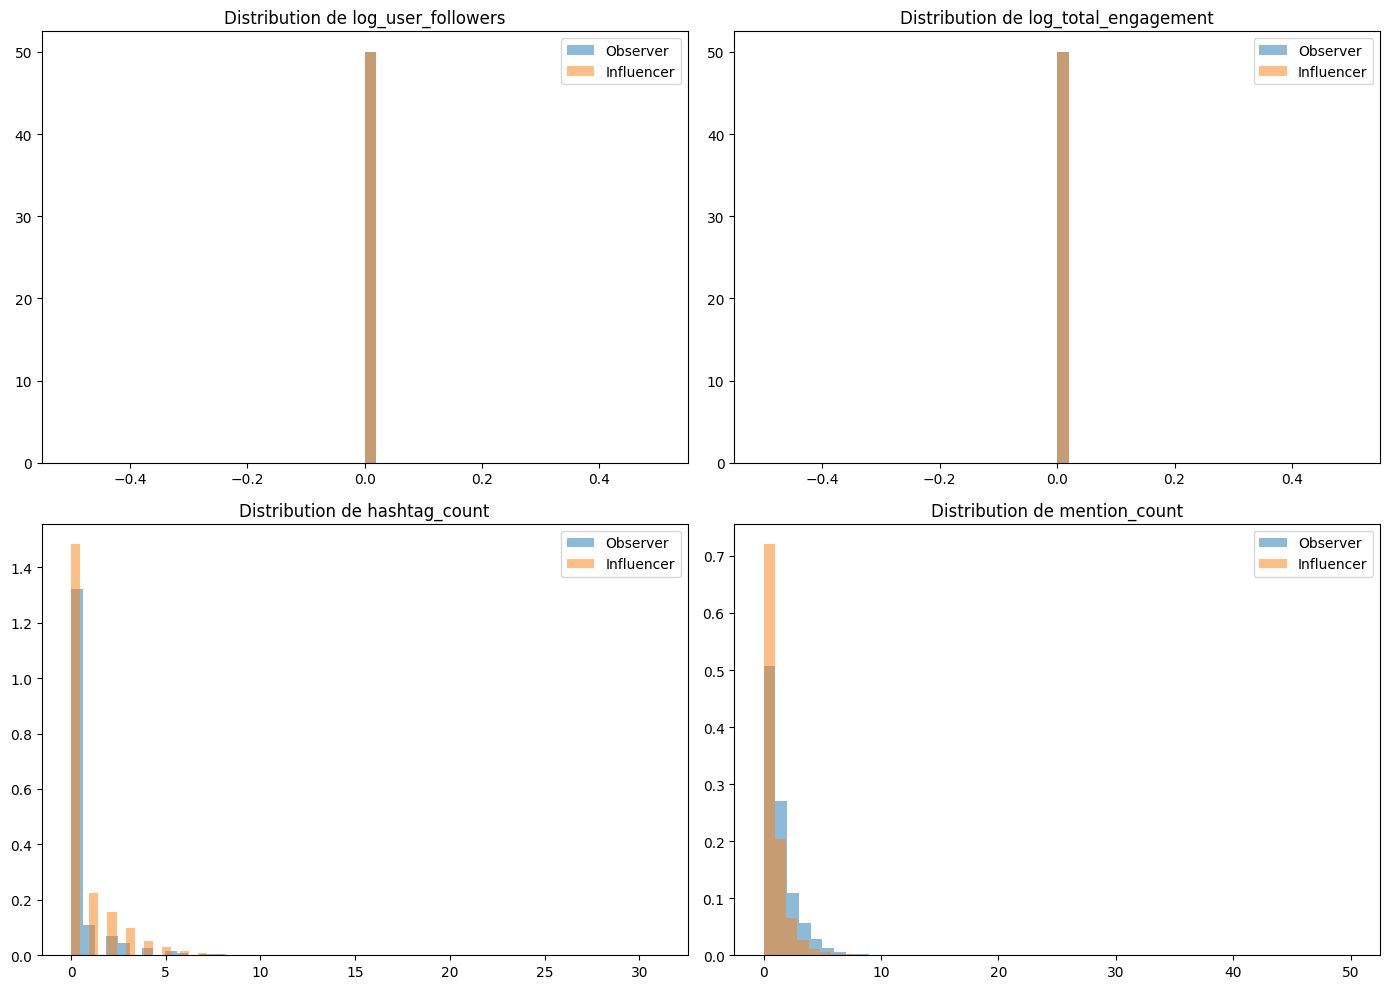

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualisation
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Distribution des features clés par label
features_to_plot = ['log_user_followers', 'log_total_engagement', 'hashtag_count', 'mention_count']

for ax, feat in zip(axes.flatten(), features_to_plot):
    for label in [0, 1]:
        data = train_df[train_df['label'] == label][feat]
        label_name = 'Influencer' if label == 1 else 'Observer'
        ax.hist(data, bins=50, alpha=0.5, label=label_name, density=True)
    ax.set_title(f'Distribution de {feat}')
    ax.legend()

plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150)
plt.show()

In [22]:
# Comparaison moyennes par classe
comparison = train_df.groupby('label')[numeric_cols].mean().T
comparison.columns = ['Observer', 'Influencer']
comparison['Diff'] = comparison['Influencer'] - comparison['Observer']
comparison['Diff_pct'] = (comparison['Diff'] / (comparison['Observer'].abs() + 1e-8)) * 100

print("Différences moyennes entre Influencers et Observers:")
comparison.sort_values('Diff_pct', ascending=False).head(20)

Différences moyennes entre Influencers et Observers:


,Observer,Influencer,Diff,Diff_pct
user_listed_count,6.791010,132.786559,125.995548,1855.328430
is_tweetdeck,0.003955,0.030883,0.026928,680.804079
is_bot_source,0.007209,0.045570,0.038361,532.126901
entities_symbols,0.000121,0.000637,0.000516,426.404947
user_statuses_count,10693.365145,43771.451426,33078.086281,309.332804
user_has_url,0.162869,0.564341,0.401472,246.500801
user_geo_enabled,0.249921,0.539604,0.289683,115.909535
url_count,0.265525,0.499114,0.233589,87.972647
user_favourites_count,10700.279810,19938.501592,9238.221782,86.336264
has_url,0.245325,0.402229,0.156904,63.957467


## 💾 Sauvegarde des Features

In [23]:
# Sauvegarder les features extraites
train_df.to_csv('data/train_features.csv', index=False)
test_df.to_csv('data/test_features.csv', index=False)

print(f"Features sauvegardées!")
print(f"  - Train: data/train_features.csv ({train_df.shape})")
print(f"  - Test: data/test_features.csv ({test_df.shape})")

Features sauvegardées!
  - Train: data/train_features.csv ((154914, 63))
  - Test: data/test_features.csv ((103380, 63))


## 🧪 Test Rapide avec LightGBM

In [24]:
from sklearn.model_selection import cross_val_score
from lightgbm import LGBMClassifier

# Préparer les données
feature_cols = [c for c in numeric_cols if c not in ['challenge_id', 'label']]
X = train_df[feature_cols].fillna(0)
y = train_df['label']

print(f"Features utilisées: {len(feature_cols)}")
print(f"X shape: {X.shape}")

# Model simple
lgbm = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=7,
    num_leaves=31,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

# Cross-validation
scores = cross_val_score(lgbm, X, y, cv=5, scoring='accuracy')
print(f"\nCross-validation Accuracy: {scores.mean():.4f} (+/- {scores.std()*2:.4f})")

Features utilisées: 59
X shape: (154914, 59)

Cross-validation Accuracy: 0.8354 (+/- 0.0064)

Cross-validation Accuracy: 0.8354 (+/- 0.0064)


Top 20 features les plus importantes:
                    feature  importance
45      user_statuses_count        1004
46    user_favourites_count         992
47        user_listed_count         834
51  user_description_length         752
18          uppercase_ratio         241
6              tweet_length         223
2             hashtag_count         196
8                word_count         170
24                is_iphone         167
52             user_has_url         149
53     user_default_profile         136
11            mention_count         114
55         user_geo_enabled         101
26                   is_web          98
16                url_count          94
4               emoji_count          79
19        exclamation_count          75
25               is_android          68
40            entities_urls          63
39        entities_hashtags          62


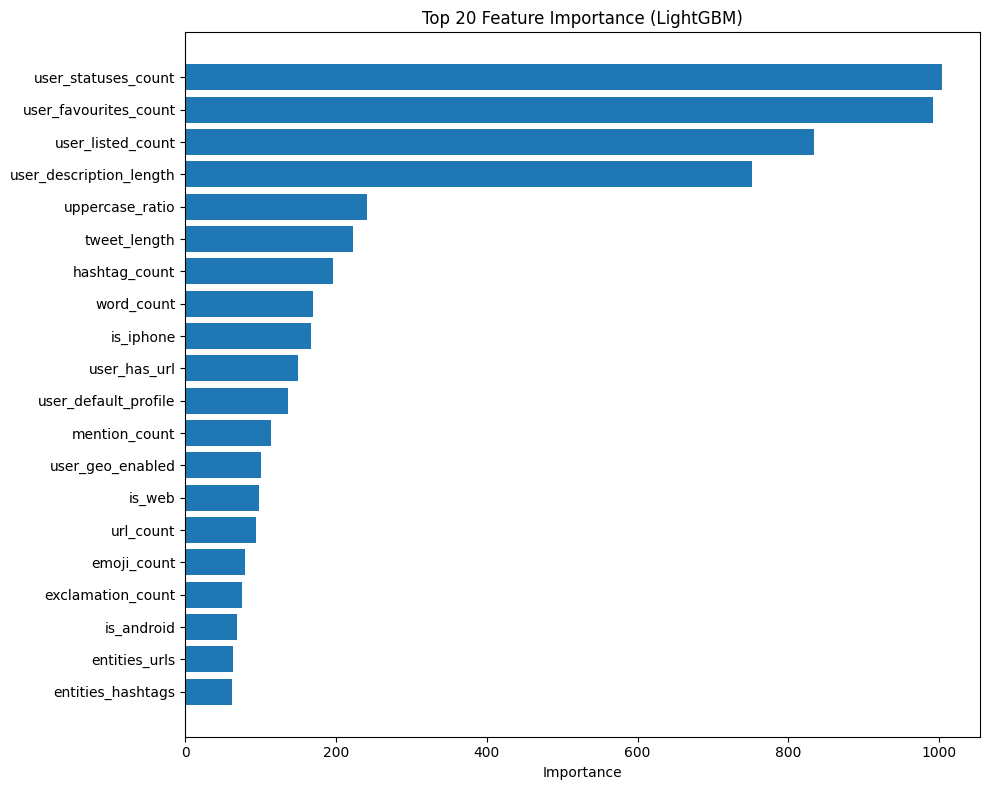

In [25]:
# Feature importance
lgbm.fit(X, y)
importance = pd.dataFrame({
    'feature': feature_cols,
    'importance': lgbm.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 20 features les plus importantes:")
print(importance.head(20))

# Plot
plt.figure(figsize=(10, 8))
plt.barh(importance.head(20)['feature'], importance.head(20)['importance'])
plt.xlabel('Importance')
plt.title('Top 20 Feature Importance (LightGBM)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

## 🚀 Génération des Prédictions

In [26]:
# Préparer test set
X_test = test_df[feature_cols].fillna(0)

# Prédictions
predictions = lgbm.predict(X_test)

# Créer submission
submission = pd.dataFrame({
    'id': test_df['challenge_id'],
    'label': predictions
})

submission.to_csv('submission_features.csv', index=False)
print(f"Submission sauvegardée: submission_features.csv")
print(f"Distribution des prédictions:")
print(submission['label'].value_counts(normalize=True))

Submission sauvegardée: submission_features.csv
Distribution des prédictions:
label
0    0.559044
1    0.440956
Name: proportion, dtype: float64


## ✅ Résumé Phase 2

### Features Extraites:

**Textuelles (22 features):**
- Call-to-action, self-promotion patterns
- Hashtags, emojis, mentions counts
- Tweet length, word count
- Reply/quote status
- URLs, uppercase ratio, punctuation

**Structurées (20 features):**
- Source (device)
- Engagement metrics (retweet, favorite, reply, quote counts)
- Log-transformed engagement
- Entities counts

**Utilisateur (15 features):**
- Followers, friends, statuses counts
- Verified status
- Followers/friends ratio
- Profile features

**NLP (optionnel, 12 features):**
- Sentiment (stars, positive/negative/neutral)
- NER (person, org, location counts)

### Prochaines étapes:
- Combiner avec TF-IDF (baseline.ipynb)
- Utiliser dans ensemble/stacking
- Fine-tuner les hyperparamètres